Imports

In [97]:
# data structures
import numpy as np
import pandas as pd
# plotting
import seaborn as sns
import matplotlib.pyplot as plt
# URLs
from pathlib import Path
import urllib.request
# ML
import sklearn

Constants

In [98]:
RANDOM = 42

# Data exploration
Load the Data.

In [99]:
data_root = "./data"
data = pd.read_csv(f"{data_root}/housing/housing.csv")

## Look at the general Data. 
Check what kind of data we are working with. e.g. What columns, what datatypes, etc

In [100]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Notice that total_bedrooms contains less values than all other columns. This means we are missing data and need to take care of this later on.

In [101]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The `ocean_proximity` column is a string but it seems repetivie, so lets look at this attribute more closely.

In [102]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

The are only 5 unqiues values for the `ocean_proximity`. This is a categorical attribute.

The describe function shows a summay of numerical attributes. 

In [103]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


It is also important to visualize the data using graphs. The `df.hist()` function automatically plots a histrogram for each numerical attribute in the dataframe. This is a good first step to understanding the data distributions. 

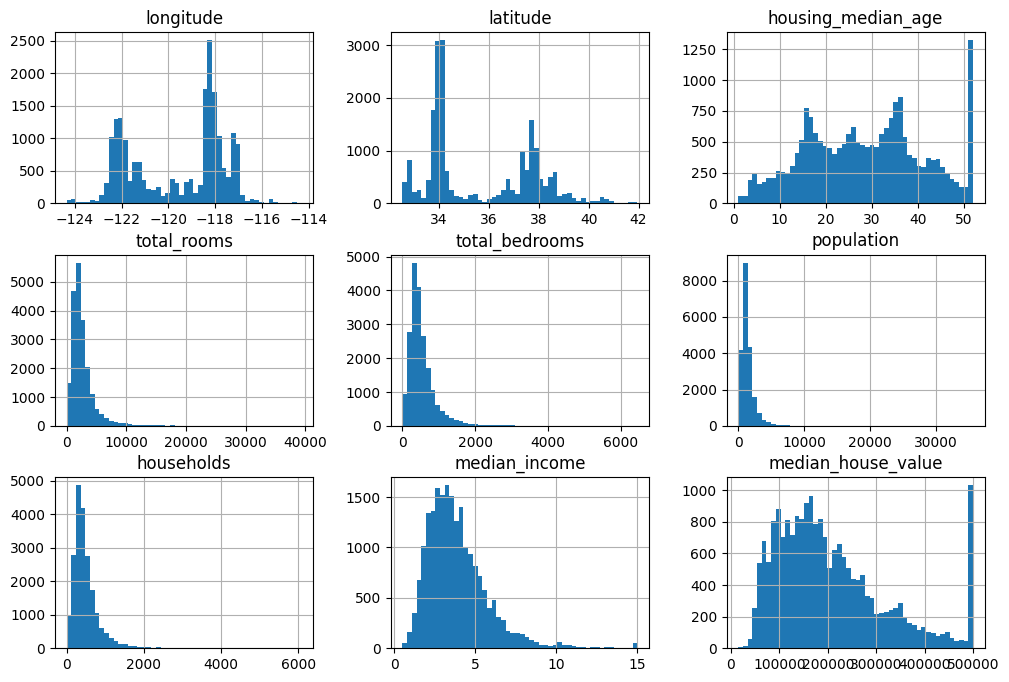

In [104]:
data.hist(bins=50, figsize=(12, 8))
plt.show()

## Generate Test Set 
We generate a test set using stratified sampling. 

According to experts the median income is very important to predict median housing prices. So we want to do Stratified sampling based on income categories. Since the `median_income` is a continous value, we have to create a `income_category` attribute.

Looking at the histogram of `median_income` above, we realize that most values are clustered in the range of 1.5 - 6. (i.e. 15,000$ - 60,000$).

We create 5 income categories:

In [105]:
data["income_category"] = pd.cut(data["median_income"], [0.0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])

Lets visualize the income categories.

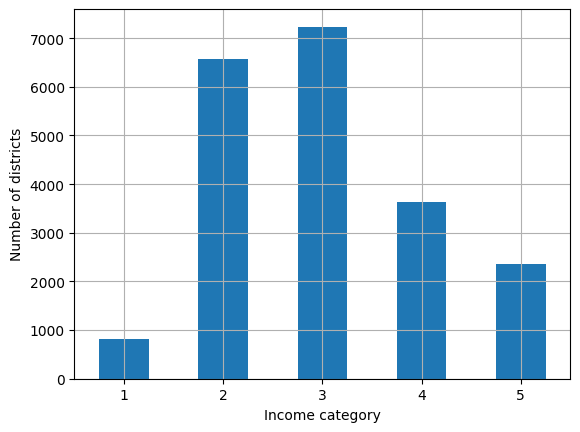

In [106]:
cat_counts = data["income_category"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

The category seems solid, so lets use it for the stratified sampling.

In [107]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(data, test_size=0.2, stratify=data["income_category"], random_state=RANDOM)

Let's verify if the stratified sampling was successful by looking at the income category distribution. (Plot the Sampling bias comparison of stratified versus purely random sampling)

In [108]:
def income_cat_proportions(df):
    return df["income_category"].value_counts() / len(df)

compare_props = pd.DataFrame({
    "All Data %": income_cat_proportions(data),
    "Stratified %": income_cat_proportions(strat_test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["All Data %"] - 1)
(compare_props * 100).round(2)

,All Data %,Stratified %,Strat. Error %
Income Category,,,
1,3.98,4.00,0.36
2,31.88,31.88,-0.02
3,35.06,35.05,-0.01
4,17.63,17.64,0.03
5,11.44,11.43,-0.08


The income category distribution of the full dataset is nearly identical to the income category distribution of the test data set. This means that the stratified sampling worked as intended.

Since we only created the `income_category` attribute for the stratified sampling, we can now drop this column. 

In [109]:
data.drop("income_category", axis="columns", inplace=True)
strat_train_set.drop("income_category", axis="columns", inplace=True)
strat_test_set.drop("income_category", axis="columns", inplace=True)

In [110]:
print()

## Discover and visualize data to gain insights
We have only taken a quick glance at the data. Let's go a little more in depth.

Let's create a copy of the train set that we will explore. Since the data set is quite small, we can just explore the train set directly. If we had a huge dataset, we would sample a small exploration set.

In [111]:
explore = strat_train_set.copy()

### Geographical Data
We are working with geographical data, so lets create a scatterplot of the geo-coordinates.

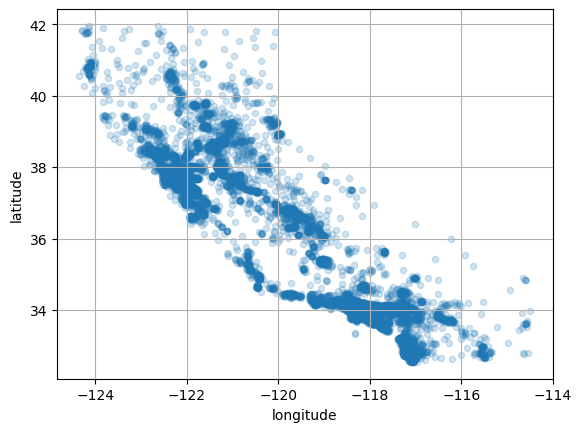

In [112]:
explore.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

This shows us where the majority of our datapoints are. But the goal is to predict the housing price, so let's include this in the plot

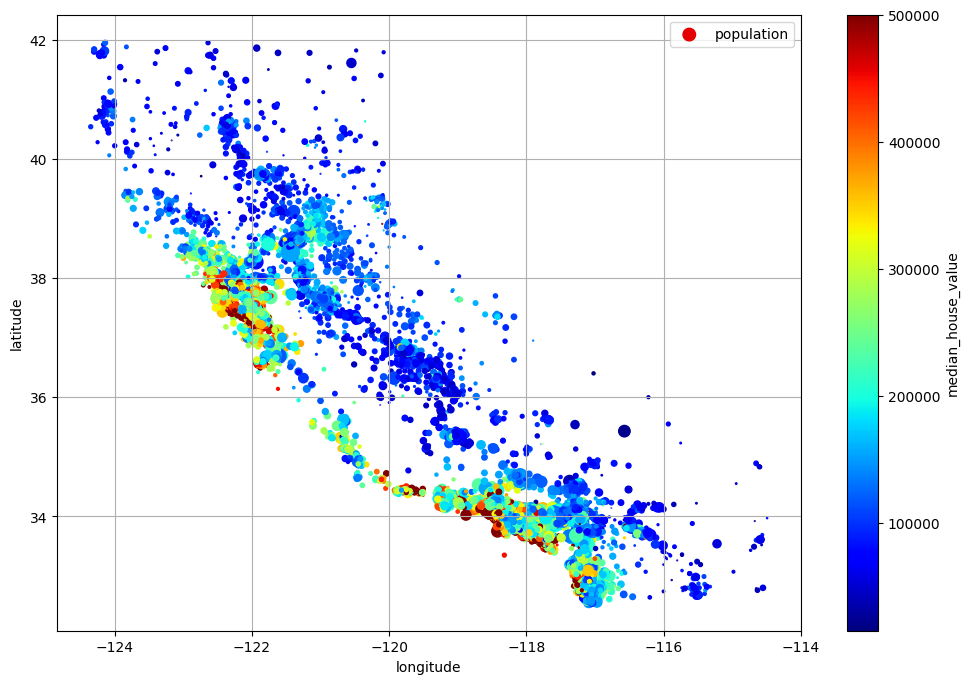

In [113]:
explore.plot(kind="scatter", x="longitude", y="latitude", grid=True, 
            s=explore["population"] / 100, label="population",
            c="median_house_value", cmap="jet", colorbar=True,
            legend=True, sharex=False, figsize=(12, 8))
plt.show()

The radius of the circle represents the districts population (option `s`), and the color represents the price (option `c`).
The resulting graphs shows us that housing prices are closely related to location (e.g. closer to the ocean = higher price) and to the population density.

For an even better graph, let's add the map of carlifornia.

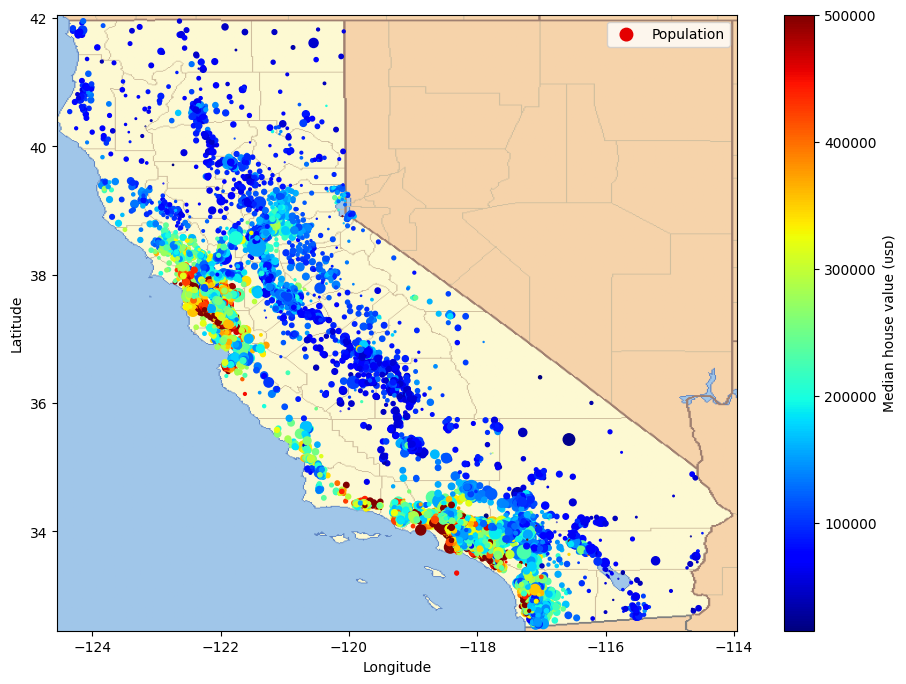

In [114]:
filename = "california.png"
filepath = Path(f"data/{filename}")
if not filepath.is_file():
    homlp_root = "https://github.com/ageron/handson-mlp/raw/main/"
    url = homlp_root + "images/end_to_end_project/" + filename
    urllib.request.urlretrieve(url, filepath)

housing_renamed = explore.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(12, 8))

california_img = plt.imread(filepath)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)
plt.show()

Here you can clearly see how impactful the distance to the ocean is.

### Looking for correlations
Lets see what attributes correlate with our target label (`median_house_value`)

In [115]:
corr_matrix = explore.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Let's focus on the attributes that are most correlated with the median housing value. Plot them using the `pandas scatter_matrix()` function. 

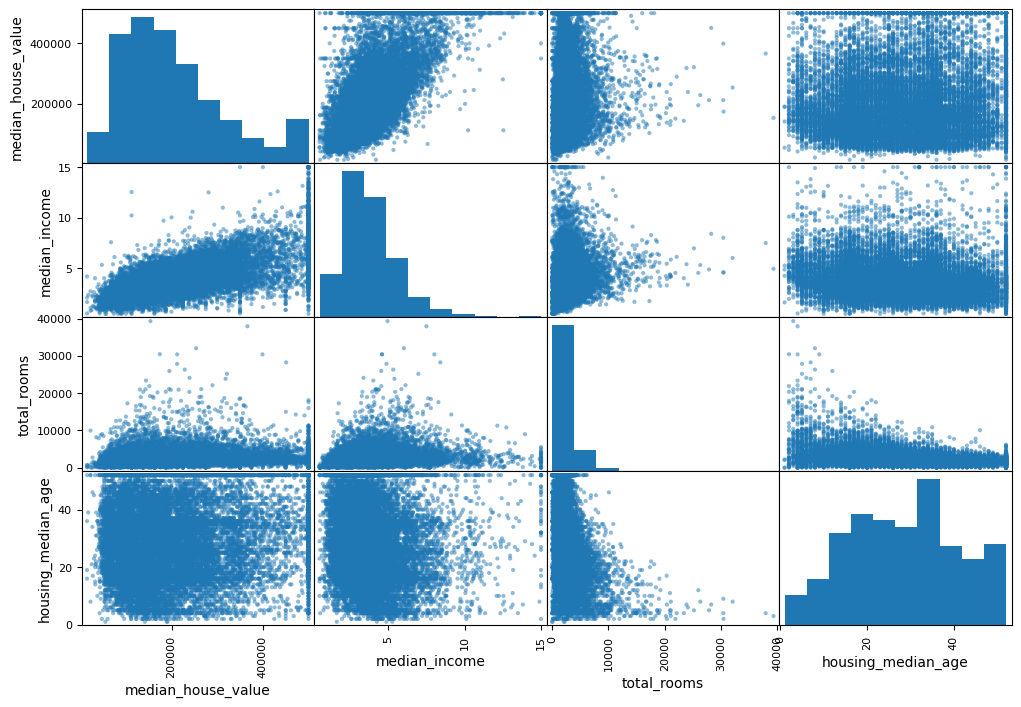

In [116]:
positively_corr_attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
pd.plotting.scatter_matrix(explore[positively_corr_attributes], figsize=(12, 8))
plt.show()

Since median income has the strongest correlation coefficient and looks very linearly correlated to the meidan house value, lets look at it in more detail

<Axes: xlabel='median_income', ylabel='median_house_value'>

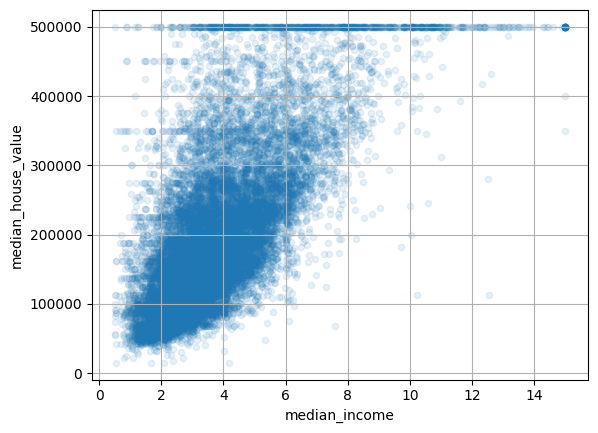

In [117]:
explore.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)

This plot re-affirms the strong linear correlation. Additionally we can observe the horizontal line at 50000$. This means that there is a price cap for the median house value.
## Attribute Combinations
The total number of rooms in a district is not very useful if you don’t know how many households there are. What we are really after is the number of rooms per household. The same goes for the total number of bedrooms, instead we are interested in the ratio of bedtooms to total rooms.  

In [118]:
explore["rooms_per_house"] = explore["total_rooms"] / explore["households"]
explore["bedrooms_to_total_rooms_ratio"] = explore["total_bedrooms"] / explore["total_rooms"]
explore["people_per_house"] = explore["population"] / explore["households"]
corr_matrix = explore.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value               1.000000
median_income                    0.688380
rooms_per_house                  0.143663
total_rooms                      0.137455
housing_median_age               0.102175
households                       0.071426
total_bedrooms                   0.054635
population                      -0.020153
people_per_house                -0.038224
longitude                       -0.050859
latitude                        -0.139584
bedrooms_to_total_rooms_ratio   -0.256397
Name: median_house_value, dtype: float64

The new `bedrooms_to_total_rooms_ratio` has a strong negative correlation to our target label. This means that houses with a lower bedroom/room ratio tend to be more expensive. 

The number of `rooms_per_house` is also more informative than the `total_rooms` in a district. Obviously the larger the houses, the more expensive they are.
# Preprocessing: Prepare the Data for Machine Learning Algorithms
Let's start off by reverting to the original trainign set and seperating the features and label.

In [119]:
housing = strat_train_set.drop("median_house_value", axis='columns')
labels = strat_train_set["median_house_value"].copy()

## Clean the Data
The `total_bedrooms` attribute has missing values. Most machine learnign algorithms cannot handle missing values. We can take care of this by:
1. Removing the entire attribute
2. Removing rows of data containing missing/null values
3. **imputation**: Set the missing value to some other value (zero, mean, median, etc)

We choose **option 3** since it is the least destructive, using the `median`.

The median can only be computed on numerical attributes. We need to create a copy of the data with only the numerical attributes (`housing_num`)

In [120]:
from sklearn.impute import SimpleImputer

housing_num = housing.select_dtypes(include=[np.number])

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(housing_num)

The imputer returns a numpy array. We can simply wrap `X` in pandas dataframe using the index & columns of `housing_num`

In [121]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [122]:
null_rows_idx = housing.isnull().any(axis=1)

Here is a before/after comparison.

In [123]:
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [124]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


The imputer replaced all `NaN` values of `total_bedrooms` with the median (434).

### Removing Outliers
If your dataset contains outliers that reduce the quality of your model, now is a good time to remove them! This step will be skipped here.

## Handling Text and Categorical Attributes
The datset has 1 categorical attritube, the `ocean_proximity`.

In [125]:
housing_categories = housing[["ocean_proximity"]]
housing_categories.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [126]:
housing_categories.value_counts()

ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

Most Ml algorithms prefer to work with numbers, so let's convert this categorical attribute into a number.

We use a technique called `one-hot encoding`. This creates a binary attritube per category, distinctly identifying what category a datapoint belongs to, without the model learning unwanted patterns, as can be the case with `ordinal encoding`.

In [127]:
from sklearn.preprocessing import OneHotEncoder

category_encoder = OneHotEncoder()
housing_categories_1hot_encoded = category_encoder.fit_transform(housing_categories)

In [128]:
category_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Feature Scaling and Transformation
Currently the attributes are on completely different scales. e.g.
- total number of rooms ranges: `6-39320`, 
- median income: `0-15`
This would make the model biased to the total number of rooms, since it has a higher average value. To fix this, we use apply a `scaling` technique.

Here is an example using a `StandardScaler`. For each value: it substracts the mean and then divides by the standard deviation.

$$z = \frac{x - \mu}{s}$$

where `u` is the mean of the training samples, and `s` is the standard deviation of the training samples.

In [129]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

Plot to verify the transformed values.

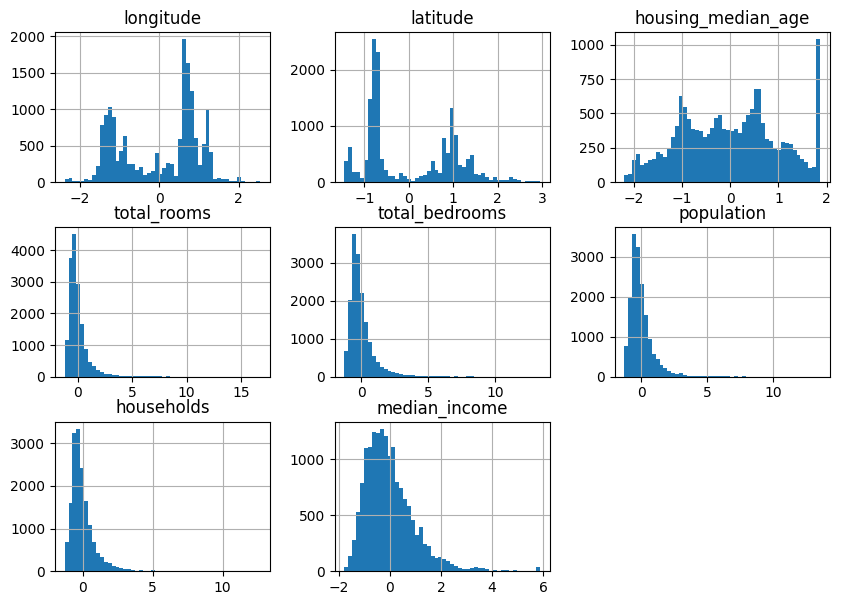

In [130]:
housing_tr_std_scaled = pd.DataFrame(housing_num_std_scaled, columns=housing_num.columns, index=housing_num.index)
housing_tr_std_scaled.hist(bins=50, figsize=(10,7))
plt.show()

Here is an example using a `MinMaxScaler`. The default configuration scales all values to the range of 0-1.

In [131]:
from sklearn.preprocessing import MinMaxScaler

std_scaler = MinMaxScaler()
housing_num_min_max_scaled = std_scaler.fit_transform(housing_num)

Plot to verify the transformed values.

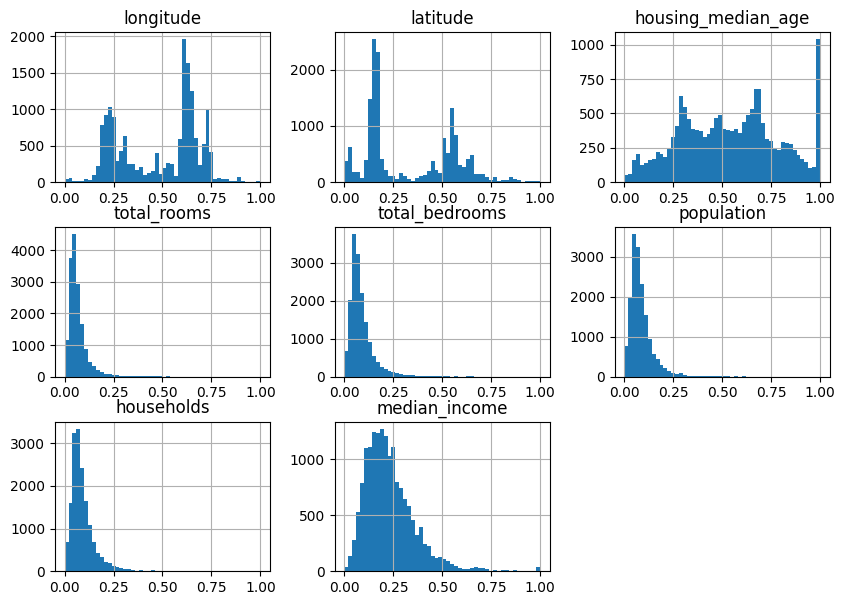

In [132]:
housing_tr_min_max_scaled = pd.DataFrame(housing_num_min_max_scaled, columns=housing_num.columns, index=housing_num.index)
housing_tr_min_max_scaled.hist(bins=50, figsize=(10,7))
plt.show()

### Custom Transformers
#### Features with heavy tail (logarithmic)
When a feature’s distribution has a heavy tail (i.e., when values far from the mean are not exponentially rare), both min-max scaling and standardization will squash most values into a small range. Machine learning models generally don’t like this. So **before** sclaing the feature, we first transform it to shrink the heavy tail, and if possible to make the distribution roughly symmetrical.

Generally for positive features with a heavy tail to the right you can:
- apply the square root
- raise the feature to a power between 0 and 1

For features with a really long and heavy tail, such as a *power law distribution* you can:
- apply a logarithm

For example the population feature is close to a *power law distribution*. Let's replace it with its logarithm using a custom transformer.

In [133]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

Applying the logarithm converts the the very long-tailed population distribtuon to something more closely resembling a *Gaussian distribution*.

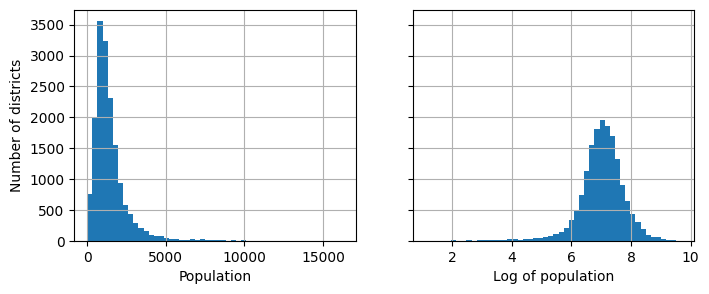

In [134]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
log_pop["population"].hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
plt.show()

#### Cluster Similarity Features
Latitude and Longitude are abstract concepts to a ML Algorithm. In order to understand the locality of districts better, we can create a new feature based on cluster similatires. We use *k-means* to detect 10 clusters. Then we calculate the Gaussian RBF similarity between each district and the 10 clusters.

In [135]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

Now we can cluster the districts based on `latitude` & `longitude`

In [136]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=RANDOM)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

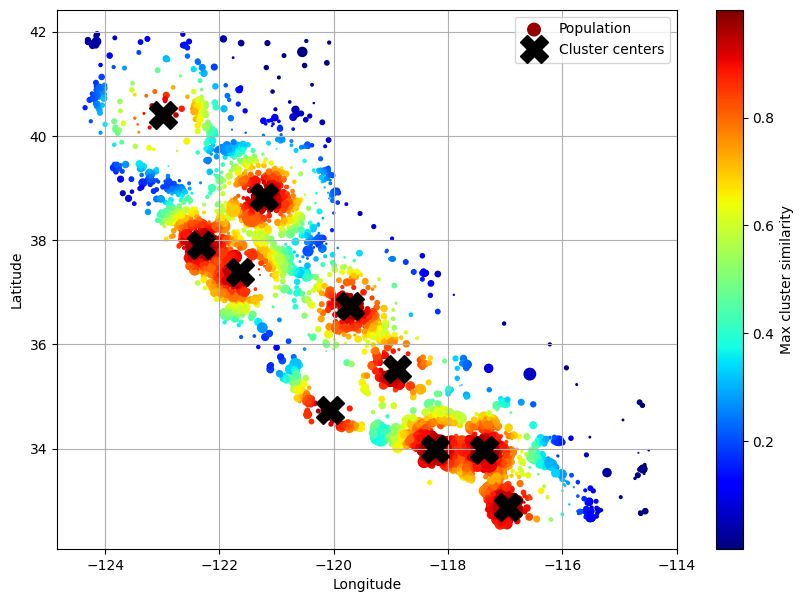

In [137]:
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")

plt.show()

## Transformation Pipelines
In order to apply multiple tranformations sequentially, we can use the sklearn `Pipieline` object or the `make_pipeline`.

In [138]:
from sklearn.pipeline import Pipeline


num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In a Jupyter Notebook pipelines can be visualized using `sklearn.set_config(display='diagram')`

This pipeline will:
1. Impute all values using the median via a `SimpleImputer`
2. Standardize all values using a `StandardScaler`

In [139]:
sklearn.set_config(display='diagram')
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('impute', ...), ('standardize', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accoun

The pipeline is fit using the `fit()` function and then depending on the final estiamtor, either calls:
- `transform()` if the final estimator is a transformer
- `predict()` if the final estimator is a predictor

The final estiamtor for `num_pipeline` is a `StandardScaler` (a tranformers), so we can use the pipeline by calling:
1. `num_pipeline.fit(data)`
2. `num_pipeline.transform(data)`

Or for convinience do it in a single `num_pipeline.fit_transform(data)` function.

In [140]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)

Lets check some rows that are `NaN` values in the original dataset.

In [141]:
df_housing_num_prepared = pd.DataFrame(housing_num_prepared, columns=num_pipeline.get_feature_names_out(),index=housing_num.index)
df_housing_num_prepared.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-0.548283,2.279293,-1.078806,1.237219,-0.24627,0.984219,1.050034,-0.144950
18217,0.806335,-0.753668,0.510343,-0.250045,-0.24627,0.300966,-0.253335,-0.242578
11889,0.761348,-0.748980,0.351428,-0.590971,-0.24627,-0.299164,-0.634681,0.222674
20325,0.346465,-0.688040,-1.078806,0.741617,-0.24627,0.251640,0.441447,0.651665
14360,0.851323,-0.945865,-1.635008,-0.628496,-0.24627,-0.959582,-0.827966,3.135282


As expected, the imputation and standardization have been applied squentially.
### Tranforming Numerical and Categorical Attributes together
The num pipeline only works on numerical values, but our dataset also contains categorical values. It would be much nicer if we can transform the entire dataset using a single pipeline. The `ColumnTransformer` from sklearn provides this functionality. It applies a pipeline to a pre-defined set of columns.

Meaning we can simply create 2 pipelines:
1. `num_pipeline` for the numerical values.
2. `cate_pipeline` for categorical values.

`num_pipeline` is already defined above, so lets create a pipeline for categorical values.

In [142]:
from sklearn.pipeline import make_pipeline
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

The `SimpleImputer` is redundant here since `ocean_proximity` column is not missing any values, but it is good to include as an insurance.

Now we have both pipelines and can create the `ColumnTransformer`.

In [143]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

Since the dataset might contain a large number of attributes that we want to use, we can use the `make_column_selector` function to select all columns for a specific type. e.g., numeric values and objects.

Additionally, if we do not want to name the pipelines inside of the `ColumnTransformer`, we can use the `make_column_transformer` that automatically does this for us. (Similarly to to `Pipeline` and `make_pipeline`)

In [144]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

Now we can apply the preprocessing pipeline to our training set.

In [145]:
housing_preprocessed = preprocessing.fit_transform(housing)

Let's verify the result.

In [146]:
housing_preprocessed_df = pd.DataFrame(housing_preprocessed, columns=preprocessing.get_feature_names_out(), index=housing.index)
housing_preprocessed_df.loc[null_rows_idx].head()

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
14452,-0.548283,2.279293,-1.078806,1.237219,-0.24627,0.984219,1.050034,-0.144950,0.0,1.0,0.0,0.0,0.0
18217,0.806335,-0.753668,0.510343,-0.250045,-0.24627,0.300966,-0.253335,-0.242578,1.0,0.0,0.0,0.0,0.0
11889,0.761348,-0.748980,0.351428,-0.590971,-0.24627,-0.299164,-0.634681,0.222674,1.0,0.0,0.0,0.0,0.0
20325,0.346465,-0.688040,-1.078806,0.741617,-0.24627,0.251640,0.441447,0.651665,1.0,0.0,0.0,0.0,0.0
14360,0.851323,-0.945865,-1.635008,-0.628496,-0.24627,-0.959582,-0.827966,3.135282,1.0,0.0,0.0,0.0,0.0


### Combining all Transformations
Let's create a single coherent pipeline that applies all of the transformations we have used up until now! This provides a good overview of what steps we are applying to the data and makes it reproduceable.

The pipeline will:
1. **Impute missing values:** Numerical features will use the median. Categorical features will be replaced by the most frequent category.
2. One-Hot Encode Categorical Features
3. Add new ratio features based on existing features that correlate better with the label (median house value). Features to add: `people_per_house`, `rooms_per_house`, `bedrooms_ratio` (i.e. bedrooms to total rooms ratio).
4. Add Cluster Similarity Features. This should be more useful than latitude and longitude to the model.
5. Replace features with a long tail by their logarithm.
6. Standardize numerical features.

In [147]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] # feature names out
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

In [148]:
log_pipeline = make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one"),
        StandardScaler()
    )

It is also best practice to create a default pipeline, for numeric values that don't need any special treatment.

In [149]:
default_num_pipeline = make_pipeline(StandardScaler())

In [150]:
preprocessing = ColumnTransformer([
    ("category", cat_pipeline, make_column_selector(dtype_include=object)),
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"])
], remainder=default_num_pipeline) # one column remaining: housing_median_age

In [151]:
housing_prepared = preprocessing.fit_transform(housing)


In [152]:
housing_prepared.shape

(16512, 24)

In [153]:
preprocessing.get_feature_names_out()

array(['category__ocean_proximity_<1H OCEAN',
       'category__ocean_proximity_INLAND',
       'category__ocean_proximity_ISLAND',
       'category__ocean_proximity_NEAR BAY',
       'category__ocean_proximity_NEAR OCEAN', 'bedrooms__ratio',
       'rooms_per_house__ratio', 'people_per_house__ratio',
       'geo__Cluster 0 similarity', 'geo__Cluster 1 similarity',
       'geo__Cluster 2 similarity', 'geo__Cluster 3 similarity',
       'geo__Cluster 4 similarity', 'geo__Cluster 5 similarity',
       'geo__Cluster 6 similarity', 'geo__Cluster 7 similarity',
       'geo__Cluster 8 similarity', 'geo__Cluster 9 similarity',
       'log__total_bedrooms', 'log__total_rooms', 'log__population',
       'log__households', 'log__median_income',
       'remainder__housing_median_age'], dtype=object)

# Select and Train a Model
Now that the data has been preprocessed, we can move on to actually training a model.
## Train and Evaluate on the Training Set
Let's start off with the best basic Ml algorithm, the Linear Regression.

In [154]:
from sklearn.linear_model import LinearRegression

linear_regression = make_pipeline(preprocessing, LinearRegression())
linear_regression.fit(housing, labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...), ('bedrooms', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will 

Now we have a working linear regression model. Let's test it with some values from the training set.

In [155]:
predictions = linear_regression.predict(housing)
predictions[:5].round()

array([245970., 372738., 135707.,  91441., 330874.])

In [156]:
labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

This does not look very good, some predications are off by more than 25%. Let's measure the error of the model. This can be done using:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

We will use RMSE as the error function since it has the same units as the target variable, making it easier to interpret.

In [157]:
from sklearn.metrics import root_mean_squared_error
linear_regression_rmse = root_mean_squared_error(labels, predictions)
linear_regression_rmse

68972.88910758485

The model has an average error of $68,972 on the training set. Most districts range between $120,000 and $265,000, so our model is not very accurate. The model is **underfitting** the data. 

So let's try a different ML algorithm.

In [158]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=RANDOM))
tree_reg.fit(housing, labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...), ('bedrooms', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` 

In [159]:
predictions = tree_reg.predict(housing)

linear_regression_rmse = root_mean_squared_error(labels, predictions)
linear_regression_rmse

0.0

We observe a RMSE of **0.0**. This would imply a perfect model. But this obviously cannot be the case. This means we are grossly **overfitting** the data.
## Cross-Validation
Let's employ the cross-validation technique. We take the training-set and split it up again into train/test tests. This way we can evaluate the performance of the algorithm on "unseen" data multiple times. Here we use 10-fold cross validation which is usually a good rule of thumb.

In [160]:
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_reg, housing, labels, scoring="neg_root_mean_squared_error", cv=10)

In [161]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67316.127500
std       2382.142794
min      63159.984673
25%      67010.932265
50%      67692.906355
75%      68256.404802
max      71563.627494
dtype: float64

Now the model doesn't look as perfect as it did before. It is just as bad as the linear regression model we trained earlier. Let's try one more algorithm to see if it can save us.

In [162]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=RANDOM))
forest_rmses = -cross_val_score(forest_reg, housing, labels, scoring="neg_root_mean_squared_error", cv=10)

In [163]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47155.760025
std       1037.670952
min      45551.860152
25%      46724.784622
50%      47185.988796
75%      47601.121199
max      49324.240945
dtype: float64

This model looks much better, than the previous 2. Here is the point where **you should make educated guesses about what types of models might work well with your data and try them out**. But for this project we are going to assume that the `RandomForestRegressor` is good enoug.
# Fine-Tune a Model
## Grid Search
Now we need to find some appropriate hyperparamters for the `RandomForestRegressor`. One option is to use `GridSearchCV`. This technique goes through a list of possible hyperparamters and tries out all of the hyperparamter combinations and evalutes them using cross-validation.

In [164]:
from sklearn.model_selection import GridSearchCV
full_pipeline = Pipeline([
    ("preprocessing", preprocessing), 
    ("random_forest", RandomForestRegressor(random_state=RANDOM))
    ])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
    'random_forest__max_features': [6, 8, 10]},
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
scoring='neg_root_mean_squared_error')
grid_search.fit(housing, labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cr

Grid-Search is an exhaustive search, meaning it will go through all hyper-paramter combinations. Here we provided 2 dictionaries in `param_grid.`

So GridSearchCV will first evaluate all 3 × 3 = 9 combinations of n_clusters and max_features hyperparameter values specified in the first dict, then it will try all 2 × 3 = 6 combinations of hyperparameter values in the second dict. So in total the grid search will explore 9 + 6 = 15 combinations of hyperparameter values, and it will train the pipeline 3 times per combination, since we are using 3-fold cross validation. This means there will be a grand total of 15 × 3 = 45 rounds of training!

After this is done, we can get the best combination of hyperparamters.

In [165]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [166]:
def convert_cv_result(cv_results: np.nda):
    cv_res = pd.DataFrame(cv_results)
    cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
    cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                    "param_random_forest__max_features", "split0_test_score",
                    "split1_test_score", "split2_test_score", "mean_test_score"]]
    score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
    cv_res.columns = ["n_clusters", "max_features"] + score_cols
    cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
    return cv_res

In [167]:
cv_res = convert_cv_result(grid_search.cv_results_)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43333,43893,44814,44013
13,15,8,43439,44275,44994,44236
14,15,10,44224,44397,45455,44692
7,10,6,44386,44951,45603,44980
9,10,6,44386,44951,45603,44980


## Randomized Search
Because Grid Search is exhaustive, it can take quite a lot of time, if you want to explore a lot of hyperparamter combinations. We can use an alternative to grid search `GridSearchCV`, namely `RandomizedSearchCV`. It works in a similar way to grid-search, but instead of trying out all possible combinations it only evaluates a fixed numbers of combinations. These combinations are randomly selected. 

While this approach might seems inferior at fist, it has a few advantages:
- Extreme reduction in training/evaluation time.
- Continous hyperparamters do not explode the size of the search
- Less relevant hyperparamters do not increase the search length. (There might be hyperparamters that do not make any difference for the model perforamnce, so why use up resources to explore different combinations for them)

For each hyperparameter, you must provide either a list of possible values, or a probability distribution.

In [168]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features': randint(low=2, high=20)
}
rnd_search = RandomizedSearchCV( full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=RANDOM)
rnd_search.fit(housing, labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....x7f8f43b687d0>, 'random_forest__max_features': <scipy.stats....x7f8f40fd6650>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchC

In [169]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [170]:
cv_res = convert_cv_result(rnd_search.cv_results_)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41326,42111,42903,42113
8,32,7,41905,42360,43309,42525
5,42,4,42066,42777,43579,42807
0,41,16,42413,42978,43596,42996
2,23,8,42376,42934,44231,43181


# Analyzing the Best Models and Their Errors
Not all features are equally useful. After a search you can check which features are the most important.

In [171]:
final_model = rnd_search.best_estimator_ # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_

sorted(zip(feature_importances, final_model["preprocessing"].get_feature_names_out()), reverse=True)

[(np.float64(0.1774218658428657), 'log__median_income'),
 (np.float64(0.07883513510195964), 'bedrooms__ratio'),
 (np.float64(0.07766507482519434), 'category__ocean_proximity_INLAND'),
 (np.float64(0.05027079221277539), 'rooms_per_house__ratio'),
 (np.float64(0.046490017383446505), 'people_per_house__ratio'),
 (np.float64(0.03951375008012614), 'geo__Cluster 30 similarity'),
 (np.float64(0.0266905072494019), 'geo__Cluster 9 similarity'),
 (np.float64(0.02514934902759639), 'geo__Cluster 36 similarity'),
 (np.float64(0.02092403578409721), 'geo__Cluster 1 similarity'),
 (np.float64(0.017998391821716312), 'geo__Cluster 3 similarity'),
 (np.float64(0.017871306027190816), 'geo__Cluster 18 similarity'),
 (np.float64(0.01740348906309769), 'geo__Cluster 32 similarity'),
 (np.float64(0.014842993219024578), 'geo__Cluster 25 similarity'),
 (np.float64(0.014700478693176599), 'geo__Cluster 0 similarity'),
 (np.float64(0.013972064110352875), 'geo__Cluster 7 similarity'),
 (np.float64(0.0138753575692784

# Evaluate the Model on the Test Set
We found suitable hyperparamers for our model. Now it is time to evaluate the model on unseen data, i.e. the test set.

In [172]:
X_test = strat_test_set.drop("median_house_value", axis="columns")
y_test = strat_test_set["median_house_value"].copy()

In [173]:
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
final_rmse

41379.2116276919

The RMSE alone, might not be accurate enough to judge moedl performance in the real world. In order to get a better idea on how precise the estimate is, we compute the 95% confidence interval for the generalization error using `scipy.stats.bootstrap()`.

In [174]:
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = bootstrap([squared_errors], rmse, confidence_level=confidence,
                        random_state=RANDOM)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [175]:
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

95% CI for RMSE: (39445.5088, 43570.5415)


# Get the Model ready for Production
Save the model to a file. We use `joblib` here, but multiple formats are supported. Official `scikit-learn` [documentation](https://scikit-learn.org/stable/model_persistence.html) on model persistence.

In [176]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

Now you can deploy the model for production.

In [177]:
import joblib

# load all of the functions, the pipeline needs to make predictions: ...
# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [178]:
predictions

array([440125.13, 459863.11, 107949.  , 102613.  , 341539.08])